First Five Rows
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Dataset Shape: (20640, 9)

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  f

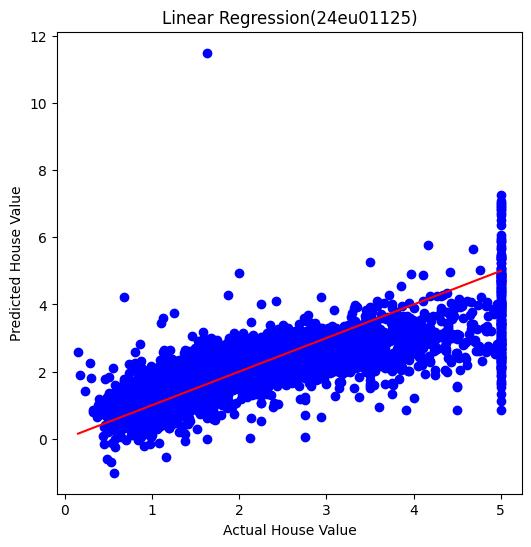


========== Support Vector Regression ==========
MAE : 0.39859907695205365
MSE : 0.357004031933865
RMSE: 0.5974981438748282
R2 Score: 0.7275628923016773


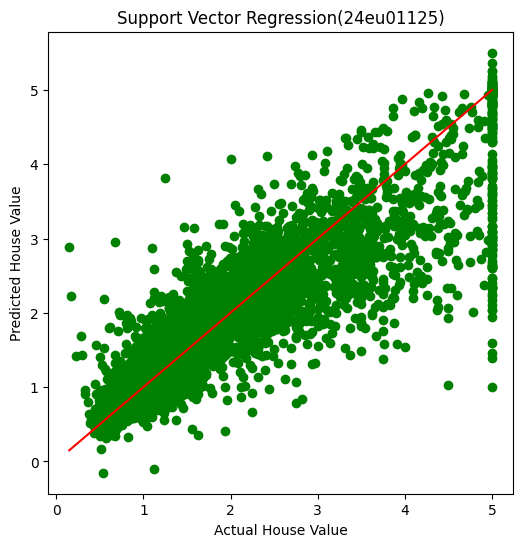


========== Decision Tree Regression ==========
MAE : 0.45467918846899225
MSE : 0.495235205629094
RMSE: 0.7037294974840077
R2 Score: 0.622075845135081


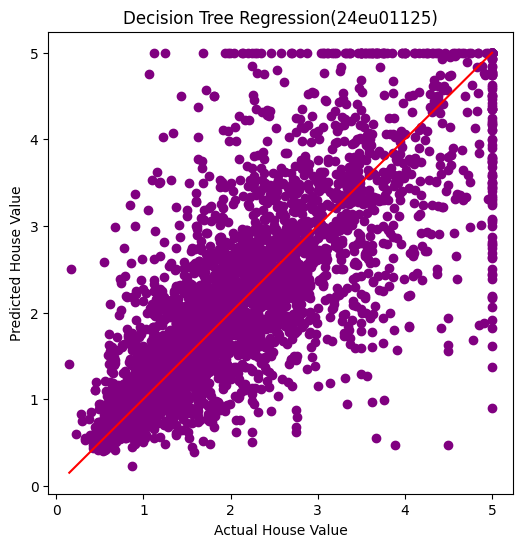


================ Model Comparison ================

                       Model       MAE       MSE      RMSE  R2 Score
0          Linear Regression  0.533200  0.555892  0.745581  0.575788
1  Support Vector Regression  0.398599  0.357004  0.597498  0.727563
2   Decision Tree Regression  0.454679  0.495235  0.703729  0.622076

Best Model
Model       Support Vector Regression
MAE                          0.398599
MSE                          0.357004
RMSE                         0.597498
R2 Score                     0.727563
Name: 1, dtype: object


In [2]:
# ================================
# California Housing Price Prediction
# Linear Regression, SVR & Decision Tree
# ================================

# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

# ================================
# Load Dataset
# ================================

california = fetch_california_housing(as_frame=True)

df = california.frame

print("First Five Rows")
print(df.head())

print("\nDataset Shape:", df.shape)

print("\nDataset Information")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

# ================================
# Features and Target
# ================================

X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

# ================================
# Train Test Split
# ================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ================================
# Feature Scaling
# ================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================================
# 1. LINEAR REGRESSION
# ==========================================================

print("\n========== Linear Regression ==========")

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_mse = mean_squared_error(y_test, lr_pred)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, lr_pred)

print("MAE :", lr_mae)
print("MSE :", lr_mse)
print("RMSE:", lr_rmse)
print("R2 Score:", lr_r2)

plt.figure(figsize=(6,6))
plt.scatter(y_test, lr_pred, color="blue")
plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Linear Regression(24eu01125)")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)
plt.show()

# ==========================================================
# 2. SUPPORT VECTOR REGRESSION
# ==========================================================

print("\n========== Support Vector Regression ==========")

svr = SVR(kernel='rbf')

svr.fit(X_train_scaled, y_train)

svr_pred = svr.predict(X_test_scaled)

svr_mae = mean_absolute_error(y_test, svr_pred)
svr_mse = mean_squared_error(y_test, svr_pred)
svr_rmse = np.sqrt(svr_mse)
svr_r2 = r2_score(y_test, svr_pred)

print("MAE :", svr_mae)
print("MSE :", svr_mse)
print("RMSE:", svr_rmse)
print("R2 Score:", svr_r2)

plt.figure(figsize=(6,6))
plt.scatter(y_test, svr_pred, color="green")
plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Support Vector Regression(24eu01125)")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)
plt.show()

# ==========================================================
# 3. DECISION TREE REGRESSION
# ==========================================================

print("\n========== Decision Tree Regression ==========")

dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_mae = mean_absolute_error(y_test, dt_pred)
dt_mse = mean_squared_error(y_test, dt_pred)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_pred)

print("MAE :", dt_mae)
print("MSE :", dt_mse)
print("RMSE:", dt_rmse)
print("R2 Score:", dt_r2)

plt.figure(figsize=(6,6))
plt.scatter(y_test, dt_pred, color="purple")
plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Decision Tree Regression(24eu01125)")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)
plt.show()

# ==========================================================
# Model Comparison
# ==========================================================

comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Support Vector Regression",
        "Decision Tree Regression"
    ],
    "MAE": [
        lr_mae,
        svr_mae,
        dt_mae
    ],
    "MSE": [
        lr_mse,
        svr_mse,
        dt_mse
    ],
    "RMSE": [
        lr_rmse,
        svr_rmse,
        dt_rmse
    ],
    "R2 Score": [
        lr_r2,
        svr_r2,
        dt_r2
    ]
})

print("\n================ Model Comparison ================\n")
print(comparison)

# ==========================================================
# Best Model
# ==========================================================

best_model = comparison.loc[comparison["R2 Score"].idxmax()]

print("\nBest Model")
print(best_model)